In [1]:
import pandas as pd
import matplotlib.pyplot as plt

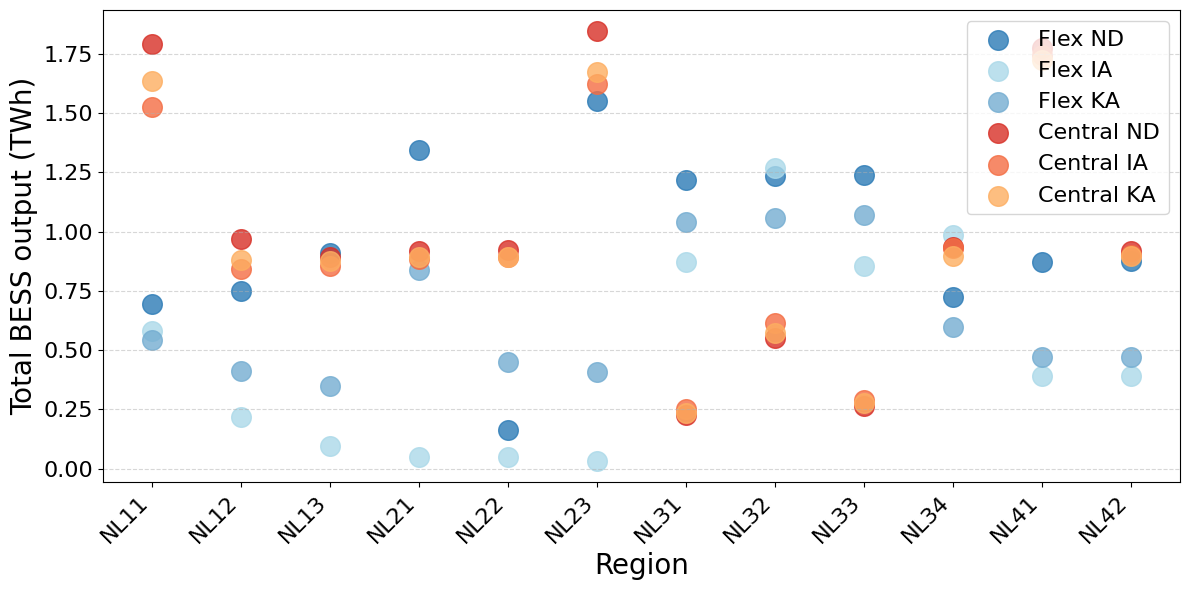

In [25]:
# Define scenario files and color scheme
scenario_files = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}

scenario_data = {}

# Process each scenario
for file, scenario in scenario_files.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (bss_liion::electricity)
    bess_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    bess_df.loc[:, "loc"] = bess_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Aggregate carrier_prod over the full year per location & convert to TWh
    bess_annual_sum = bess_df.groupby("loc")["carrier_prod"].sum().reset_index()
    bess_annual_sum["carrier_prod"] /= 1000  # Convert GWh to TWh
    
    # Store the results
    scenario_data[scenario] = bess_annual_sum

# Merge all data
plot_df = pd.concat(scenario_data, names=["Scenario"]).reset_index()

# Define color tints
color_scheme = {
    "Flex ND": "#2c7bb6",  # Dark blue
    "Flex IA": "#abd9e9",  # Light blue
    "Flex KA": "#74add1",  # Medium blue
    "Central ND": "#d73027",  # Dark red
    "Central IA": "#f46d43",  # Medium red
    "Central KA": "#fdae61"   # Light red
}

# Plot
plt.figure(figsize=(12, 6))
for scenario in scenario_files.values():
    subset = plot_df[plot_df["Scenario"] == scenario]
    plt.scatter(subset["loc"], subset["carrier_prod"], 
                color=color_scheme[scenario], marker="o", s=200, alpha=0.8, label=scenario)

plt.xticks(rotation=45, ha="right", fontsize=16)  # Increase font size for x-axis values
plt.yticks(fontsize=16)  # Increase font size for y-axis values
plt.ylabel(r"Total BESS output (TWh)", fontsize=20)
plt.xlabel(r"Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("bess_output_scenarios_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()


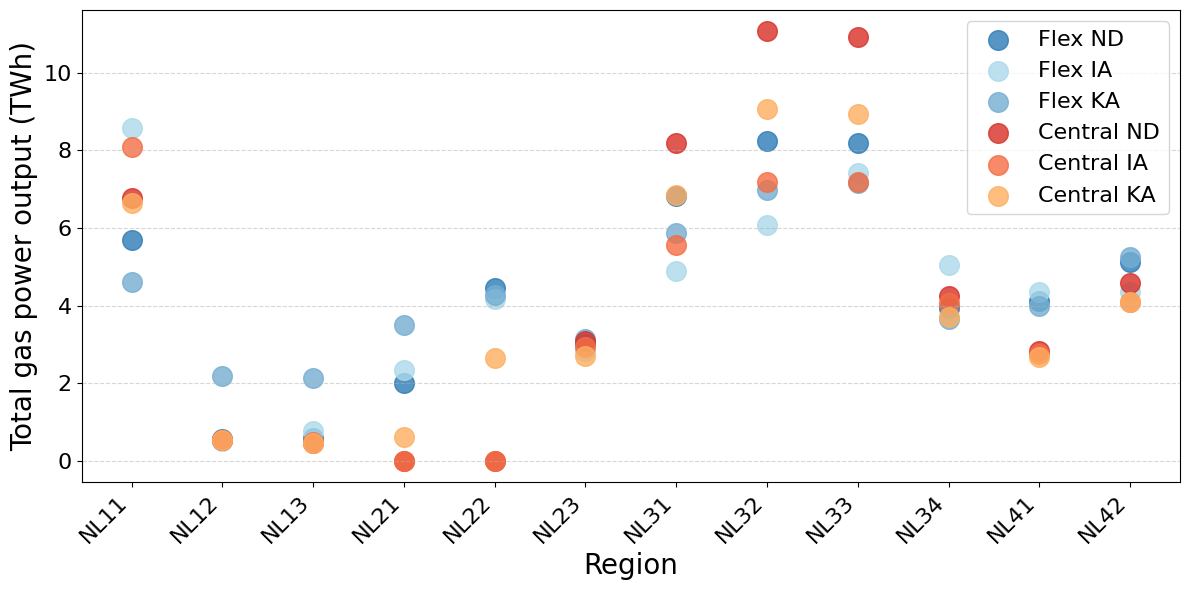

In [26]:
# Define scenario files and color scheme
scenario_files = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}

scenario_data = {}

# Process each scenario
for file, scenario in scenario_files.items():
    df = pd.read_csv(file)
    
    # Filter for gas power plants (pp_ccgt_gas::electricity)
    gas_df = df[df["loc_tech_carriers_prod"].str.contains("pp_ccgt_gas::electricity")].copy()
    
    # Extract location
    gas_df.loc[:, "loc"] = gas_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Aggregate carrier_prod over the full year per location & convert to TWh
    gas_annual_sum = gas_df.groupby("loc")["carrier_prod"].sum().reset_index()
    gas_annual_sum["carrier_prod"] /= 1000  # Convert GWh to TWh
    
    # Store the results
    scenario_data[scenario] = gas_annual_sum

plot_df = pd.concat(scenario_data, names=["Scenario"]).reset_index()

color_scheme = {
    "Flex ND": "#2c7bb6",  # Dark blue
    "Flex IA": "#abd9e9",  # Light blue
    "Flex KA": "#74add1",  # Medium blue
    "Central ND": "#d73027",  # Dark red
    "Central IA": "#f46d43",  # Medium red
    "Central KA": "#fdae61"   # Light red
}

# Plot
plt.figure(figsize=(12, 6))
for scenario in scenario_files.values():
    subset = plot_df[plot_df["Scenario"] == scenario]
    plt.scatter(subset["loc"], subset["carrier_prod"], 
                color=color_scheme[scenario], marker="o", s=200, alpha=0.8, label=scenario)

plt.xticks(rotation=45, ha="right", fontsize=16)  
plt.yticks(fontsize=16)  
plt.ylabel(r"Total gas power output (TWh)", fontsize=20)
plt.xlabel(r"Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("gas_output_scenarios_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()


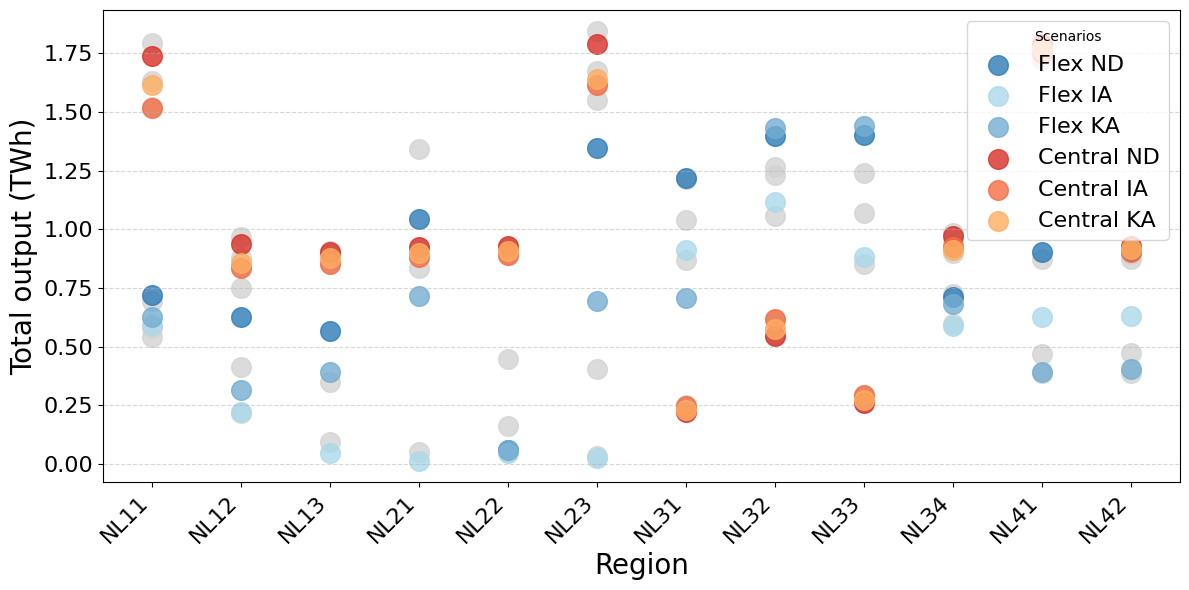

In [13]:
# ---- 1) READ & AGGREGATE THE OLD (BASE) SCENARIO DATA  ----
scenario_files_base = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}

base_scenario_data = {}

for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter for the "base" output (previously BESS).
    # Adjust this filter as needed:
    base_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location from the "loc_tech_carriers_prod" string
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Aggregate total yearly output (carrier_prod), converting GWh -> TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # Convert GWh to TWh
    
    base_scenario_data[scenario] = base_annual_sum

# Combine into one DataFrame
base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

# ---- 2) READ & AGGREGATE THE NEW SCENARIO DATA ----
scenario_files_new = {
    "gas_bess_flex_nd.csv": "Flex ND",
    "gas_bess_flex_ia.csv": "Flex IA",
    "gas_bess_flex_ka.csv": "Flex KA",
    "gas_bess_central_nd.csv": "Central ND",
    "gas_bess_central_ia.csv": "Central IA",
    "gas_bess_central_ka.csv": "Central KA"
}

new_scenario_data = {}

for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)

    # Filter out the "new" output (previously 'gas').
    # Adjust this filter as needed:
    new_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Aggregate total yearly output (carrier_prod), converting GWh -> TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    new_scenario_data[scenario] = new_annual_sum

# Combine into one DataFrame
new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()
color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))

for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    plt.scatter(
        subset["loc"], 
        subset["carrier_prod"], 
        color="lightgrey",       # old points are grey
        marker="o", 
        s=200, 
        alpha=0.8, 
        label=None               # hide legend label for these grey points
    )

for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    plt.scatter(
        subset["loc"], 
        subset["carrier_prod"], 
        color=color_scheme[scenario], 
        marker="o", 
        s=200, 
        alpha=0.8, 
        label=scenario
    )

# --- Formatting ---
plt.xticks(rotation=45, ha="right", fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel(r"Total output (TWh)", fontsize=20)
plt.xlabel(r"Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16, title="Scenarios")
plt.tight_layout()
# plt.savefig("base_and_new_output_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()

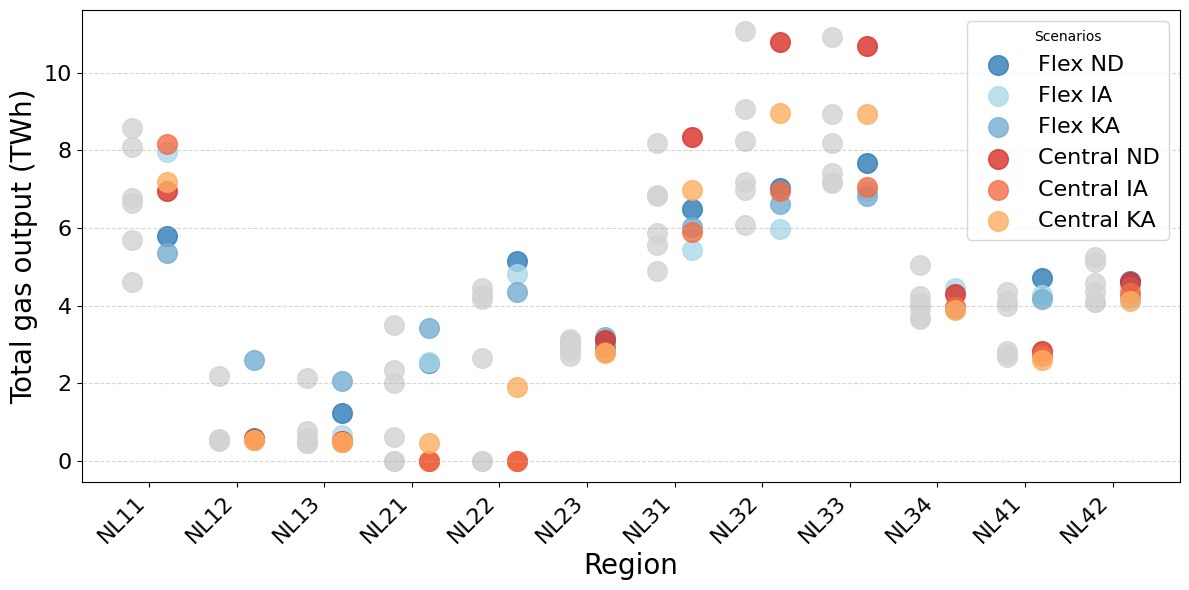

In [14]:
scenario_files_base = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}

base_scenario_data = {}

for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter out the "base" gas output
    # Adjust the filter below if you need something more specific than just "gas"
    base_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    base_scenario_data[scenario] = base_annual_sum

base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

scenario_files_new = {
    "gas_bess_flex_nd.csv": "Flex ND",
    "gas_bess_flex_ia.csv": "Flex IA",
    "gas_bess_flex_ka.csv": "Flex KA",
    "gas_bess_central_nd.csv": "Central ND",
    "gas_bess_central_ia.csv": "Central IA",
    "gas_bess_central_ka.csv": "Central KA"
}

new_scenario_data = {}

for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter out the "new" gas output
    new_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    
    new_scenario_data[scenario] = new_annual_sum
new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()

# All region names from both dataframes
all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))

# Dictionary to map region -> integer index
loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

# Define a color scheme for your scenarios
color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))

# Offset values
offset_base = -0.2
offset_new =  0.2

#Plot BASE scenario data in light grey (shifted left) ---
for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color="lightgrey",
        marker="o",
        s=200,
        alpha=0.8,
        label=None  # no label for the grey points
    )

# Plot NEW scenario data in color 
for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario
    )

plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total gas output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16, title="Scenarios")
plt.tight_layout()
# plt.savefig("gas_output_TWh_shifted.pdf", dpi=300, bbox_inches="tight")
plt.show()

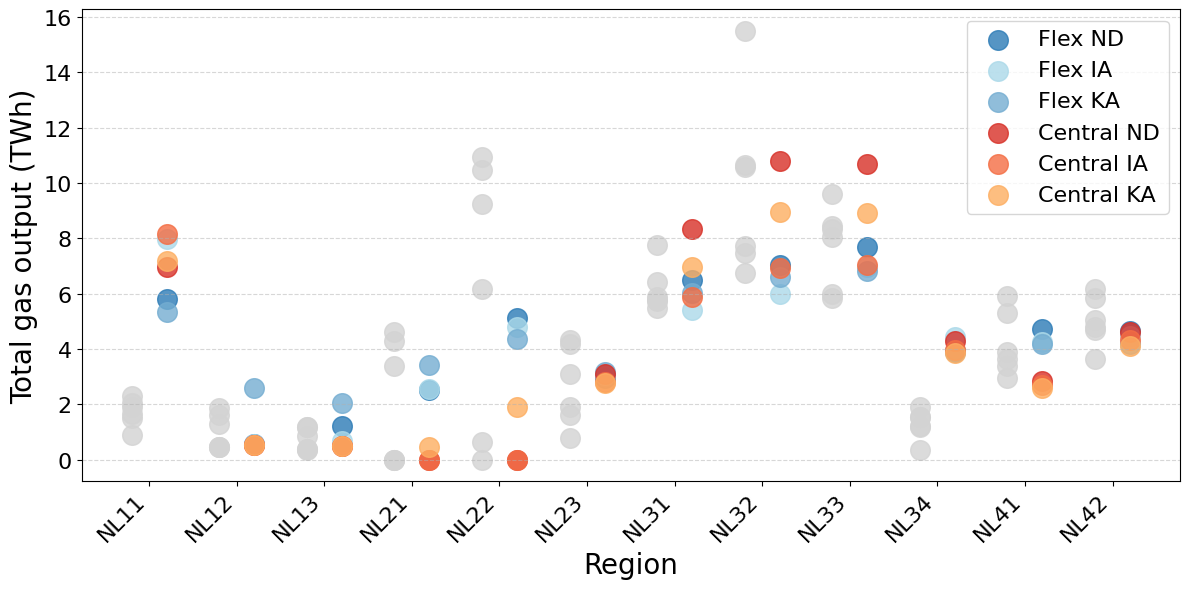

In [12]:
# READ & AGGREGATE THE BASE SCENARIO DATA ----
scenario_files_base = {
    "Line loading opt/gas_bess_flex_nd_ll.csv": "Flex ND",
    "Line loading opt/gas_bess_flex_ia_ll.csv": "Flex IA",
    "Line loading opt/gas_bess_flex_ka_ll.csv": "Flex KA",
    "Line loading opt/gas_bess_central_nd_ll.csv": "Central ND",
    "Line loading opt/gas_bess_central_ia_ll.csv": "Central IA",
    "Line loading opt/gas_bess_central_ka_ll.csv": "Central KA"
}
base_scenario_data = {}

for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter out the "base" gas output
    # Adjust the filter below if you need something more specific than just "gas"
    base_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    base_scenario_data[scenario] = base_annual_sum

# Concatenate all base scenario data
base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

# READ & AGGREGATE THE SCENARIO DATA ----
scenario_files_new = {
    "gas_bess_flex_nd.csv": "Flex ND",
    "gas_bess_flex_ia.csv": "Flex IA",
    "gas_bess_flex_ka.csv": "Flex KA",
    "gas_bess_central_nd.csv": "Central ND",
    "gas_bess_central_ia.csv": "Central IA",
    "gas_bess_central_ka.csv": "Central KA"
}

new_scenario_data = {}

for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter out the "new" gas output
    new_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    
    new_scenario_data[scenario] = new_annual_sum

# Concatenate all new scenario data
new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()

# MAP EACH REGION TO A NUMERIC X-COORDINATE & APPLY OFFSETS ----

# All region names from both dataframes
all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))

# Dictionary to map region -> integer index
loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

# Define a color scheme for your scenarios
color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))

# Offset values
offset_base = -0.2
offset_new =  0.2

# --- Plot BASE scenario data in light grey (shifted left) ---
for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color="lightgrey",
        marker="o",
        s=200,
        alpha=0.8,
        label=None  # no label for the grey points
    )

# Plot scenario data in color
for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario
    )
plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total gas output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("gas_output_TWh_shifted.pdf", dpi=300, bbox_inches="tight")
plt.show()


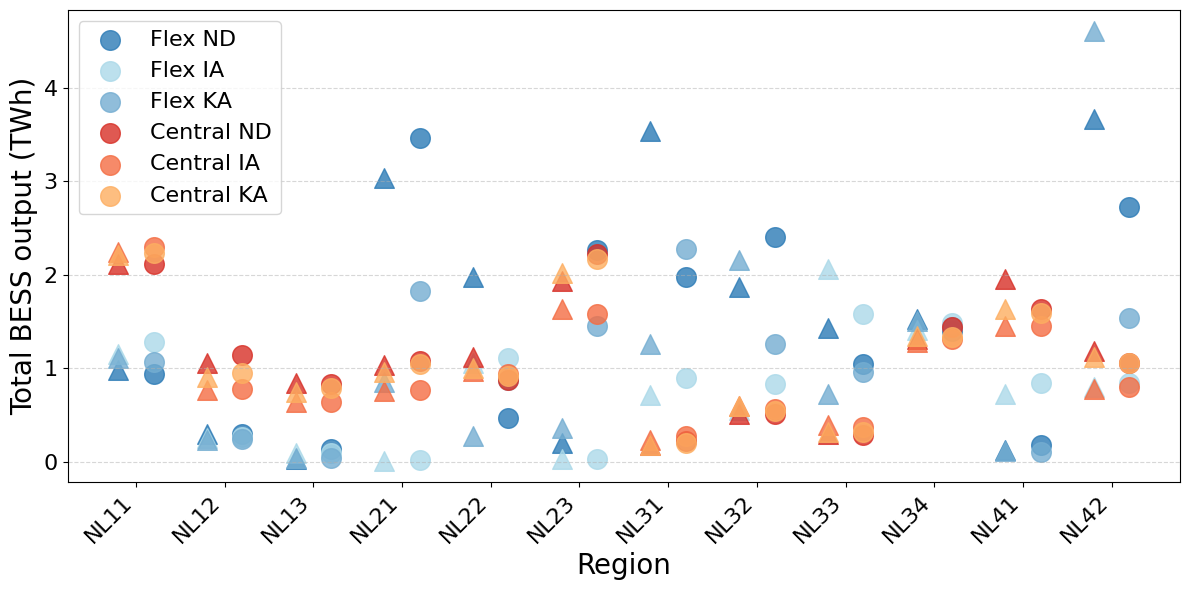

In [24]:
# READ & AGGREGATE THE BASE (OLD) SCENARIO DATA
scenario_files_base = {
    "Line loading opt/gas_bess_flex_nd_ll.csv": "Flex ND",
    "Line loading opt/gas_bess_flex_ia_ll.csv": "Flex IA",
    "Line loading opt/gas_bess_flex_ka_ll.csv": "Flex KA",
    "Line loading opt/gas_bess_central_nd_ll.csv": "Central ND",
    "Line loading opt/gas_bess_central_ia_ll.csv": "Central IA",
    "Line loading opt/gas_bess_central_ka_ll.csv": "Central KA"
}

base_scenario_data = {}
for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (old/base) scenario
    base_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert GWh -> TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    base_scenario_data[scenario] = base_annual_sum

base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

# READ & AGGREGATE THE SCENARIO DATA 
scenario_files_new = {
    "Results max pv/Line loading pv results/gas_bess_flex_nd_ll_pv.csv": "Flex ND",
    "Results max pv/Line loading pv results/gas_bess_flex_ia_ll_pv.csv": "Flex IA",
    "Results max pv/Line loading pv results/gas_bess_flex_ka_ll_pv.csv": "Flex KA",
    "Results max pv/Line loading pv results/gas_bess_central_nd_ll_pv.csv": "Central ND",
    "Results max pv/Line loading pv results/gas_bess_central_ia_ll_pv.csv": "Central IA",
    "Results max pv/Line loading pv results/gas_bess_central_ka_ll_pv.csv": "Central KA"
}

new_scenario_data = {}
for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (new) scenario
    new_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert GWh -> TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    
    new_scenario_data[scenario] = new_annual_sum

new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()

# DEFINE X-AXIS MAPPING & COLOR SCHEME 
all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))
loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))

# Offsets for side-by-side plotting
offset_base = -0.2
offset_new  =  0.2

for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],  # same color scheme
        marker="^",                    # triangle marker
        s=200,
        alpha=0.8,
        label=None                     # no legend label for base
    )

for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario  # new scenario will appear in legend
    )

plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total BESS output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("bess_shifted_output_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()

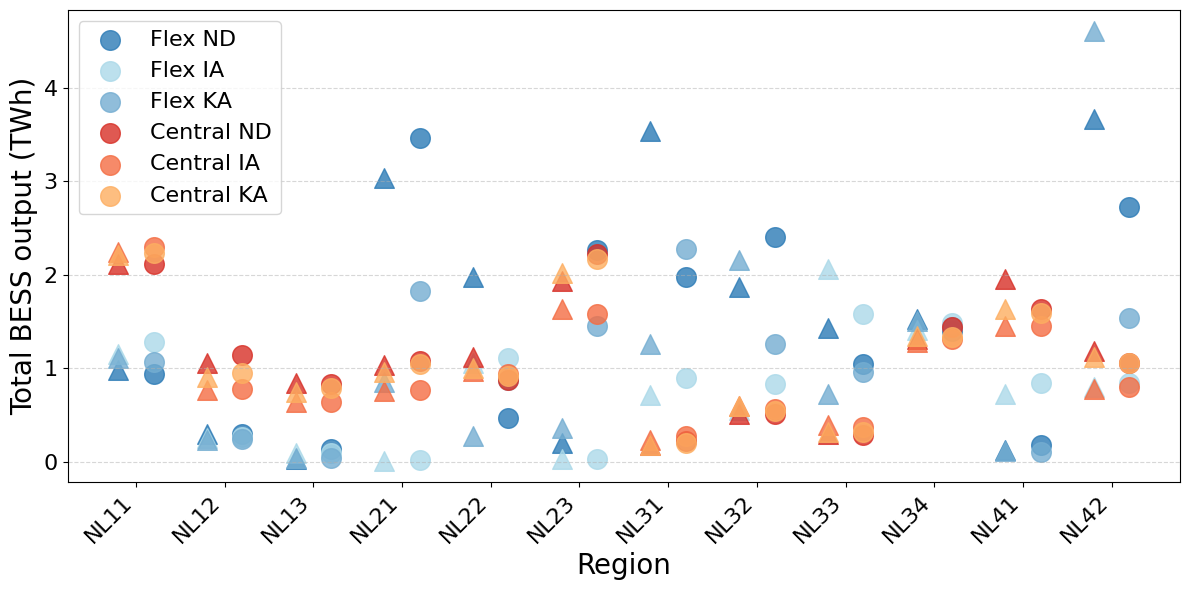

In [22]:
scenario_files_base = {
    "Line loading opt/gas_bess_flex_nd_ll.csv": "Flex ND",
    "Line loading opt/gas_bess_flex_ia_ll.csv": "Flex IA",
    "Line loading opt/gas_bess_flex_ka_ll.csv": "Flex KA",
    "Line loading opt/gas_bess_central_nd_ll.csv": "Central ND",
    "Line loading opt/gas_bess_central_ia_ll.csv": "Central IA",
    "Line loading opt/gas_bess_central_ka_ll.csv": "Central KA"
}

base_scenario_data = {}
for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    base_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  
    base_scenario_data[scenario] = base_annual_sum

base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

scenario_files_new = {
    "Results max pv/Line loading pv results/gas_bess_flex_nd_ll_pv.csv": "Flex ND",
    "Results max pv/Line loading pv results/gas_bess_flex_ia_ll_pv.csv": "Flex IA",
    "Results max pv/Line loading pv results/gas_bess_flex_ka_ll_pv.csv": "Flex KA",
    "Results max pv/Line loading pv results/gas_bess_central_nd_ll_pv.csv": "Central ND",
    "Results max pv/Line loading pv results/gas_bess_central_ia_ll_pv.csv": "Central IA",
    "Results max pv/Line loading pv results/gas_bess_central_ka_ll_pv.csv": "Central KA"
}

new_scenario_data = {}
for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (new) scenario
    new_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert GWh -> TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    new_scenario_data[scenario] = new_annual_sum

new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()

all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))
loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))
offset_base = -0.2
offset_new  =  0.2
for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],  # use scenario color
        marker="^",                    # triangle
        s=200,
        alpha=0.8,
        label=None                     # no legend label
    )

for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],  # use scenario color
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario
    )

plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total BESS output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("bess_shifted_output_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()

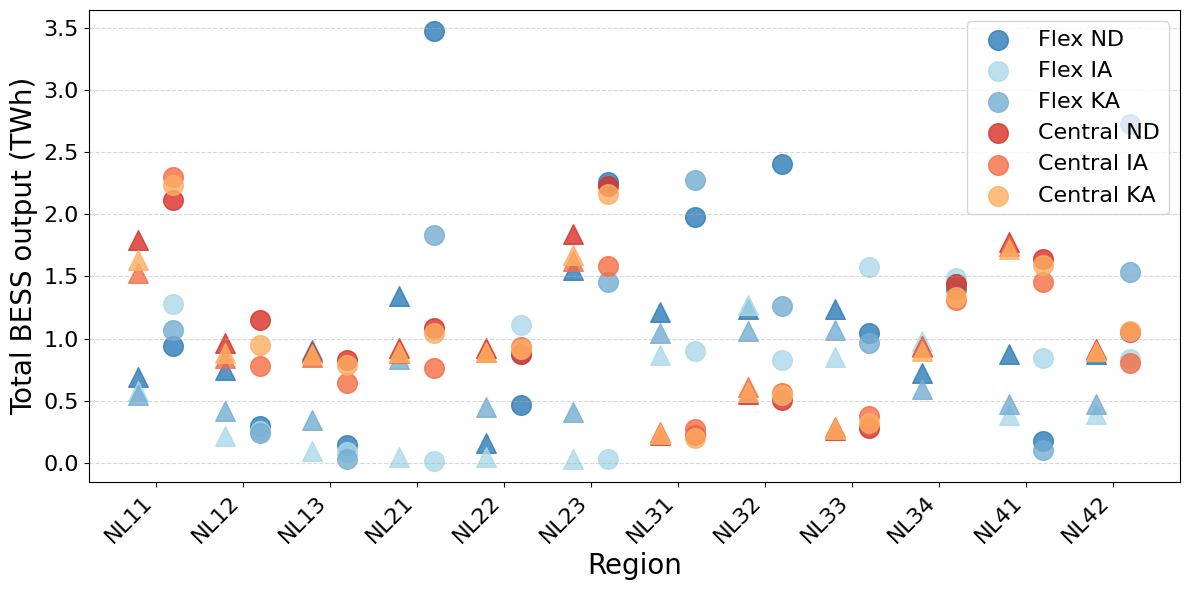

In [27]:
scenario_files_base = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}
base_scenario_data = {}
for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (old/base) scenario
    base_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert GWh -> TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    base_scenario_data[scenario] = base_annual_sum

base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

# ---- 2) READ & AGGREGATE THE NEW SCENARIO DATA ----
scenario_files_new = {
    "Results max pv/Line loading pv results/gas_bess_flex_nd_ll_pv.csv": "Flex ND",
    "Results max pv/Line loading pv results/gas_bess_flex_ia_ll_pv.csv": "Flex IA",
    "Results max pv/Line loading pv results/gas_bess_flex_ka_ll_pv.csv": "Flex KA",
    "Results max pv/Line loading pv results/gas_bess_central_nd_ll_pv.csv": "Central ND",
    "Results max pv/Line loading pv results/gas_bess_central_ia_ll_pv.csv": "Central IA",
    "Results max pv/Line loading pv results/gas_bess_central_ka_ll_pv.csv": "Central KA"
}

new_scenario_data = {}
for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter for BESS (new) scenario
    new_df = df[df["loc_tech_carriers_prod"].str.contains("bss_liion::electricity")].copy()
    
    # Extract location
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert GWh -> TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    
    new_scenario_data[scenario] = new_annual_sum

new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()

# ---- 3) DEFINE X-AXIS MAPPING & COLOR SCHEME ----
all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))
loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))

offset_base = -0.2
offset_new  =  0.2

for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],  # same color scheme
        marker="^",                    # triangle marker
        s=200,
        alpha=0.8,
        label=None                     # no legend label for base
    )

for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario  # new scenario will appear in legend
    )

plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total BESS output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("bess_shifted_output_TWh.pdf", dpi=300, bbox_inches="tight")
plt.show()

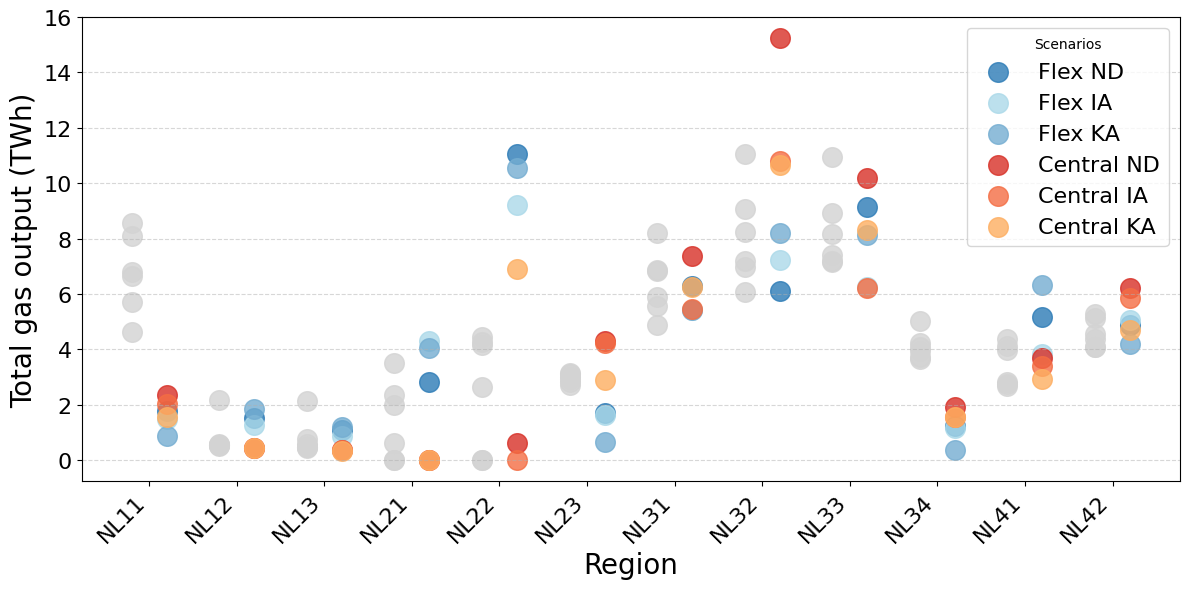

In [28]:
scenario_files_base = {
    "Results max pv/Analysis results max pv/gas_bess_flex_nd_pv.csv": "Flex ND",
    "Results max pv/Analysis results max pv/gas_bess_flex_ia_pv.csv": "Flex IA",
    "Results max pv/Analysis results max pv/gas_bess_flex_ka_pv.csv": "Flex KA",
    "Results max pv/Analysis results max pv/gas_bess_central_nd_pv.csv": "Central ND",
    "Results max pv/Analysis results max pv/gas_bess_central_ia_pv.csv": "Central IA",
    "Results max pv/Analysis results max pv/gas_bess_central_ka_pv.csv": "Central KA"
}

base_scenario_data = {}

for file, scenario in scenario_files_base.items():
    df = pd.read_csv(file)
    
    # Filter out the "base" gas output
    # Adjust the filter below if you need something more specific than just "gas"
    base_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    base_df["loc"] = base_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    base_annual_sum = base_df.groupby("loc")["carrier_prod"].sum().reset_index()
    base_annual_sum["carrier_prod"] /= 1000.0  # GWh -> TWh
    
    base_scenario_data[scenario] = base_annual_sum

base_plot_df = pd.concat(base_scenario_data, names=["Scenario"]).reset_index()

scenario_files_new = {
    "Results max pv/Line loading pv results/gas_bess_flex_nd_ll_pv.csv": "Flex ND",
    "Results max pv/Line loading pv results/gas_bess_flex_ia_ll_pv.csv": "Flex IA",
    "Results max pv/Line loading pv results/gas_bess_flex_ka_ll_pv.csv": "Flex KA",
    "Results max pv/Line loading pv results/gas_bess_central_nd_ll_pv.csv": "Central ND",
    "Results max pv/Line loading pv results/gas_bess_central_ia_ll_pv.csv": "Central IA",
    "Results max pv/Line loading pv results/gas_bess_central_ka_ll_pv.csv": "Central KA"
}

new_scenario_data = {}

for file, scenario in scenario_files_new.items():
    df = pd.read_csv(file)
    
    # Filter out the "new" gas output
    new_df = df[df["loc_tech_carriers_prod"].str.contains("gas")].copy()
    
    # Extract the region (loc)
    new_df["loc"] = new_df["loc_tech_carriers_prod"].str.split("::").str[0]

    # Sum over the year & convert from GWh to TWh
    new_annual_sum = new_df.groupby("loc")["carrier_prod"].sum().reset_index()
    new_annual_sum["carrier_prod"] /= 1000.0
    
    new_scenario_data[scenario] = new_annual_sum

new_plot_df = pd.concat(new_scenario_data, names=["Scenario"]).reset_index()
all_locs = sorted(set(base_plot_df["loc"]).union(new_plot_df["loc"]))

loc_to_x = {loc_name: i for i, loc_name in enumerate(all_locs)}

# Define a color scheme for your scenarios
color_scheme = {
    "Flex ND":   "#2c7bb6",  # Dark blue
    "Flex IA":   "#abd9e9",  # Light blue
    "Flex KA":   "#74add1",  # Medium blue
    "Central ND":"#d73027",  # Dark red
    "Central IA":"#f46d43",  # Medium red
    "Central KA":"#fdae61"   # Light red
}

plt.figure(figsize=(12, 6))
offset_base = -0.2
offset_new =  0.2

#Plot BASE scenario data in light grey
for scenario in scenario_files_base.values():
    subset = base_plot_df[base_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_base for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color="lightgrey",
        marker="o",
        s=200,
        alpha=0.8,
        label=None  # no label for the grey points
    )

# Plot NEW scenario data in color
for scenario in scenario_files_new.values():
    subset = new_plot_df[new_plot_df["Scenario"] == scenario]
    x_vals = [loc_to_x[loc] + offset_new for loc in subset["loc"]]
    y_vals = subset["carrier_prod"].values
    
    plt.scatter(
        x_vals,
        y_vals,
        color=color_scheme[scenario],
        marker="o",
        s=200,
        alpha=0.8,
        label=scenario
    )

plt.xticks(
    ticks=range(len(all_locs)),
    labels=all_locs,
    rotation=45,
    ha="right",
    fontsize=16
)
plt.yticks(fontsize=16)
plt.ylabel("Total gas output (TWh)", fontsize=20)
plt.xlabel("Region", fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=16, title="Scenarios")
plt.tight_layout()
# plt.savefig("gas_output_TWh_shifted.pdf", dpi=300, bbox_inches="tight")
plt.show()